# First-Arrival Pick Processing: Interpolation Example

This notebook walks through the processing pipeline applied to Anne's Reveal pick files
(.tbl format), demonstrating:

1. **Loading** raw picks from a Reveal .tbl file
2. **Gap detection** — splitting pick sequences at large FFID gaps (shadow zones,
   phase boundaries between direct water wave and refracted first arrivals)
3. **Interpolation** — filling in every integer FFID within each segment
4. **Boxcar smoothing** — rolling-mean filter to reduce pick jitter

The same logic runs for all 128 OBS stations via `process_anne_picks.py`
and for onshore stations via `process_onshore_picks.py`.

> **Run from the project root** (`QCF_PICKS/`) so that the relative paths below resolve correctly.

In [65]:
import json
from math import floor, log10
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE = Path(".")   # project root; change if running from elsewhere

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 1 · Load raw picks

Reveal exports picks as JSON inside a `.tbl` file.  
The relevant field is `f_of_x_picks`: a list of `[FFID, TravelTime_ms]` pairs,
where **times are in milliseconds** (reduced at V_red = 6 km/s).
We convert to seconds immediately on load.

We use **PO01A_2S24** here because it has a clear 203-FFID gap that nicely
illustrates segment splitting.  Swap `TBL_FILE` for any other station to explore.

In [68]:
TBL_FILE = BASE / "tables" / "PO01A_2S24.tbl"

with open(TBL_FILE) as f:
    data = json.load(f)

# Convert ms → s at load time so all downstream code works in seconds
raw_picks = [(p[0], p[1] / 1000.0)
             for p in sorted(data["f_of_x_picks"], key=lambda p: p[0])]
ffids_raw = [p[0] for p in raw_picks]
times_raw = [p[1] for p in raw_picks]

print(f"Station : {TBL_FILE.stem}")
print(f"Raw picks: {len(raw_picks)}")
print(f"FFID range: {ffids_raw[0]} – {ffids_raw[-1]}")
print(f"Reduced time range: {min(times_raw):.3f} – {max(times_raw):.3f} s  (V_red = 6 km/s)")

Station : PO01A_2S24
Raw picks: 104
FFID range: 22209 – 23144
Reduced time range: 1.600 – 2.583 s  (V_red = 6 km/s)


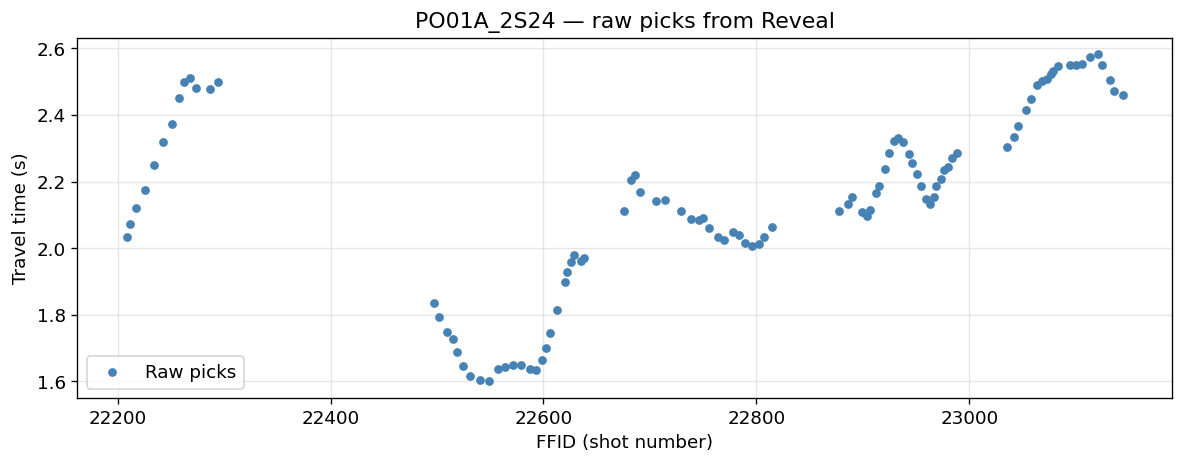

In [70]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(ffids_raw, times_raw, s=18, color="steelblue", zorder=3, label="Raw picks")
ax.set_xlabel("FFID (shot number)")
ax.set_ylabel("Travel time (s)")
ax.set_title(f"{TBL_FILE.stem} — raw picks from Reveal")
ax.legend()
plt.tight_layout()
plt.show()

## 2 · Gap detection and segment splitting

Anne picks first arrivals wherever the phase is identifiable, skipping ranges
where the wavefield is dominated by the direct water wave or where the refracted
arrival is unclear.  These gaps must **not** be interpolated across — they
represent genuine data gaps, not just missing picks.

We split the pick sequence into **segments** wherever two consecutive FFIDs
differ by more than `GAP_THRESHOLD`.  Interpolation is then applied independently
within each segment.

In [73]:
GAP_THRESHOLD = 20   # FFIDs; same default as process_anne_picks.py

# Compute all consecutive gaps
all_gaps = [
    (raw_picks[i][0] - raw_picks[i-1][0], raw_picks[i-1][0], raw_picks[i][0])
    for i in range(1, len(raw_picks))
]

# Show the distribution
gap_sizes = [g for g, _, _ in all_gaps]
print(f"Gap statistics (FFIDs between consecutive picks):")
print(f"  min={min(gap_sizes)}, median={int(np.median(gap_sizes))}, "
      f"max={max(gap_sizes)}, mean={np.mean(gap_sizes):.1f}")
print()

significant = [(g, a, b) for g, a, b in all_gaps if g > GAP_THRESHOLD]
print(f"Gaps > {GAP_THRESHOLD} FFIDs (segment boundaries):")
for size, a, b in significant:
    print(f"  FFID {a} → {b}   (gap = {size})")
if not significant:
    print("  None — all picks form a single segment")

Gap statistics (FFIDs between consecutive picks):
  min=2, median=6, max=203, mean=9.1

Gaps > 20 FFIDs (segment boundaries):
  FFID 22294 → 22497   (gap = 203)
  FFID 22638 → 22676   (gap = 38)
  FFID 22815 → 22878   (gap = 63)
  FFID 22988 → 23035   (gap = 47)


In [75]:
def split_segments(picks, gap_threshold):
    """Partition [FFID, Time] pairs into contiguous segments."""
    if not picks:
        return []
    segments, current = [], [picks[0]]
    for i in range(1, len(picks)):
        if picks[i][0] - picks[i-1][0] > gap_threshold:
            segments.append(current)
            current = []
        current.append(picks[i])
    segments.append(current)
    return segments


segments = split_segments(raw_picks, GAP_THRESHOLD)
print(f"Number of segments: {len(segments)}")
for i, seg in enumerate(segments):
    f0, f1 = seg[0][0], seg[-1][0]
    print(f"  Segment {i+1}: FFID {f0}–{f1}  ({len(seg)} picks)")

Number of segments: 5
  Segment 1: FFID 22209–22294  (13 picks)
  Segment 2: FFID 22497–22638  (25 picks)
  Segment 3: FFID 22676–22815  (20 picks)
  Segment 4: FFID 22878–22988  (26 picks)
  Segment 5: FFID 23035–23144  (20 picks)


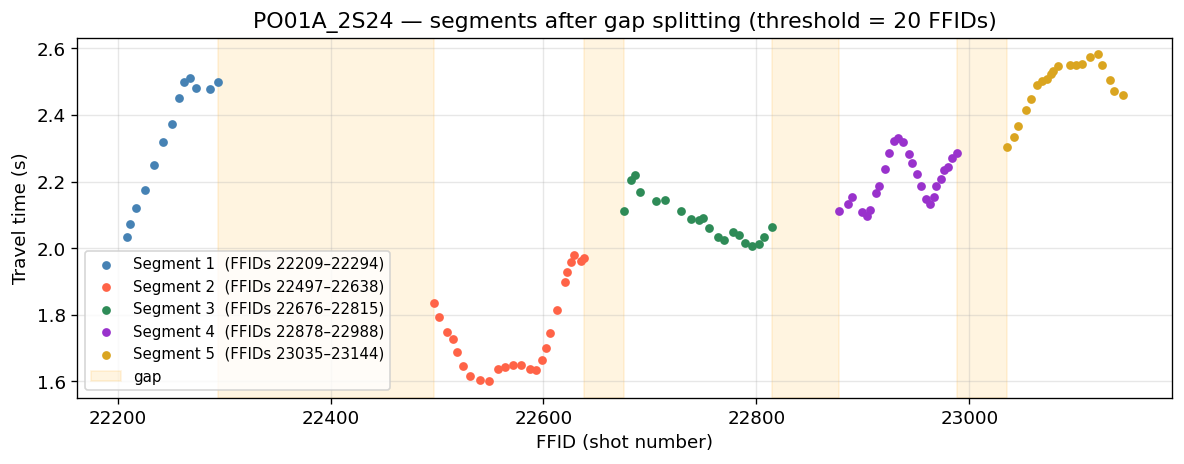

In [77]:
# Colour each segment differently so the split is visible
seg_colors = ["steelblue", "tomato", "seagreen", "darkorchid", "goldenrod"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, seg in enumerate(segments):
    color = seg_colors[i % len(seg_colors)]
    ffs = [p[0] for p in seg]
    tts = [p[1] for p in seg]
    ax.scatter(ffs, tts, s=18, color=color, zorder=3,
               label=f"Segment {i+1}  (FFIDs {ffs[0]}–{ffs[-1]})")

# Mark segment boundaries
for _, a, b in significant:
    ax.axvspan(a, b, alpha=0.12, color="orange", label="gap" if _ == significant[0][0] else "")

ax.set_xlabel("FFID (shot number)")
ax.set_ylabel("Travel time (s)")
ax.set_title(f"{TBL_FILE.stem} — segments after gap splitting (threshold = {GAP_THRESHOLD} FFIDs)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3 · Interpolation

Anne picks at roughly every 4–10 FFIDs — not every shot.  We fill in **every
integer FFID** within a segment by linear interpolation between adjacent picks.
This is required so each output row corresponds to exactly one shot position.

In [80]:
def round_sig(x, sig=7):
    if not isinstance(x, (int, float)) or x == 0:
        return x
    return round(x, sig - int(floor(log10(abs(x)))) - 1)


def interpolate_segment(picks, boxcar_window=3):
    """Linear interpolation over the full FFID range, then boxcar smoothing.
    Expects picks already in seconds (ms→s conversion done at load time).
    """
    df = pd.DataFrame(picks, columns=["FFID", "Time"])
    df["FFID"] = pd.to_numeric(df["FFID"])
    df["Time"] = pd.to_numeric(df["Time"])
    df = df.set_index("FFID")

    full_range = range(int(df.index.min()), int(df.index.max()) + 1)
    df = df.reindex(full_range).interpolate()

    df["Time"]        = df["Time"].apply(lambda x: round_sig(x, 7))
    df["Time Boxcar"] = (
        df["Time"]
        .rolling(window=boxcar_window, min_periods=1)
        .mean()
        .apply(lambda x: round_sig(x, 7))
    )
    return df.reset_index().rename(columns={"index": "FFID"})


BOXCAR_WINDOW = 3

seg_dfs = [interpolate_segment(seg, BOXCAR_WINDOW) for seg in segments]
df_all  = pd.concat(seg_dfs, ignore_index=True)

print(f"Raw picks   : {len(raw_picks)} rows")
print(f"Interpolated: {len(df_all)} rows  (one per FFID within each segment)")
for i, (seg, sdf) in enumerate(zip(segments, seg_dfs)):
    print(f"  Segment {i+1}: {len(seg)} picks → {len(sdf)} rows")

Raw picks   : 104 rows
Interpolated: 589 rows  (one per FFID within each segment)
  Segment 1: 13 picks → 86 rows
  Segment 2: 25 picks → 142 rows
  Segment 3: 20 picks → 140 rows
  Segment 4: 26 picks → 111 rows
  Segment 5: 20 picks → 110 rows


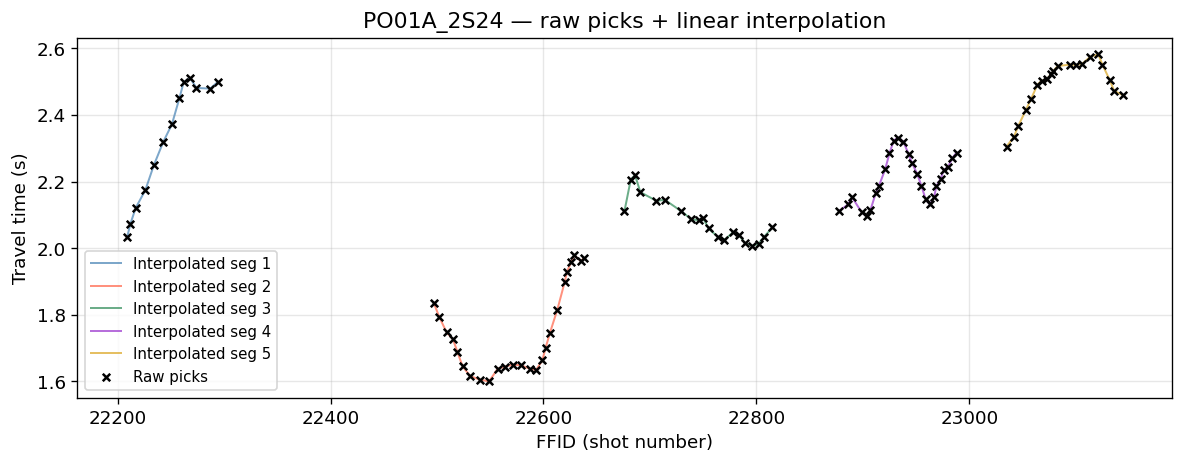

In [82]:
fig, ax = plt.subplots(figsize=(10, 4))

# Interpolated lines
for i, sdf in enumerate(seg_dfs):
    color = seg_colors[i % len(seg_colors)]
    ax.plot(sdf["FFID"], sdf["Time"], color=color, lw=1.2, alpha=0.7,
            label=f"Interpolated seg {i+1}")

# Original picks on top
ax.scatter(ffids_raw, times_raw, s=20, color="black", zorder=5,
           label="Raw picks", marker="x")

ax.set_xlabel("FFID (shot number)")
ax.set_ylabel("Travel time (s)")
ax.set_title(f"{TBL_FILE.stem} — raw picks + linear interpolation")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 4 · Boxcar (rolling-mean) smoothing

After interpolation we apply a **boxcar filter** — a rolling mean of window
width `BOXCAR_WINDOW` — to produce the `Time Boxcar` column.  This reduces
high-frequency jitter from pick noise without distorting large-scale moveout
trends.  The raw interpolated times are also preserved in the output.

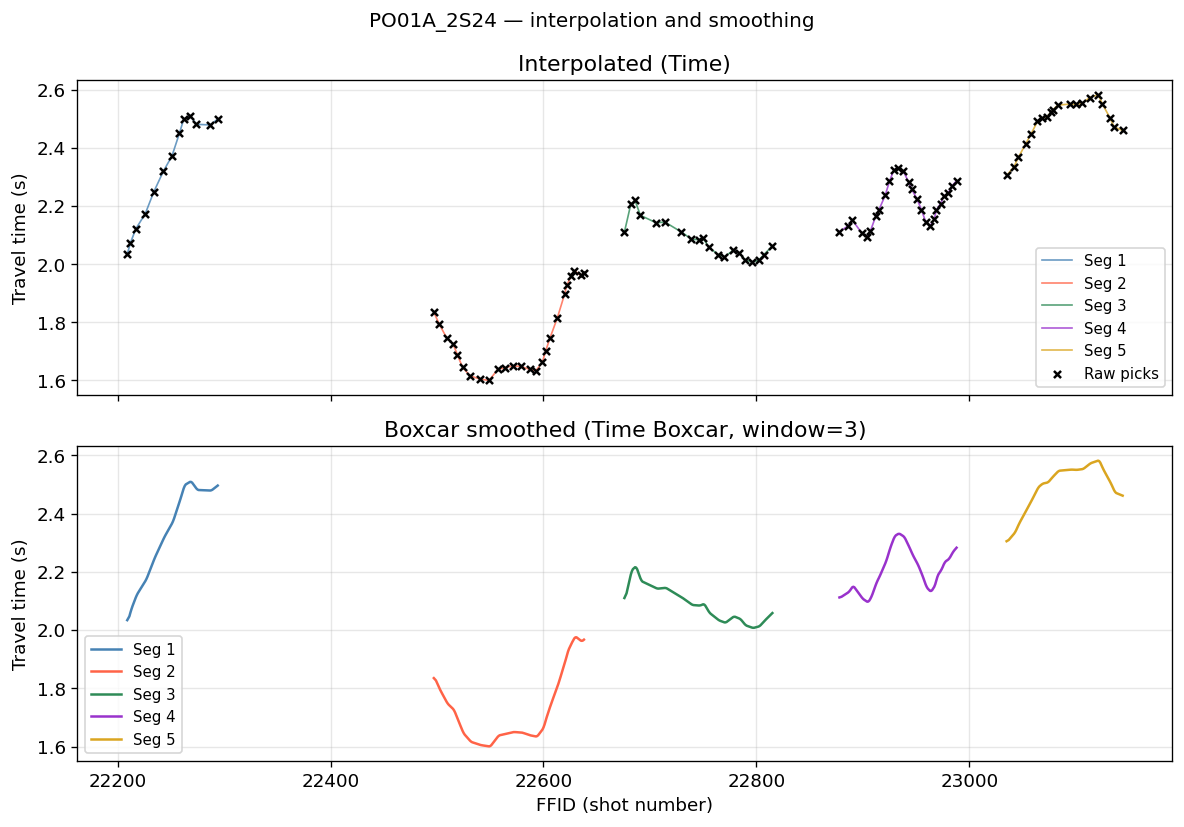

In [85]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for i, sdf in enumerate(seg_dfs):
    color = seg_colors[i % len(seg_colors)]
    axes[0].plot(sdf["FFID"], sdf["Time"],
                 color=color, lw=1, alpha=0.8, label=f"Seg {i+1}")
    axes[1].plot(sdf["FFID"], sdf["Time Boxcar"],
                 color=color, lw=1.5, label=f"Seg {i+1}")

axes[0].scatter(ffids_raw, times_raw, s=18, color="black", zorder=5,
                label="Raw picks", marker="x")

axes[0].set_ylabel("Travel time (s)")
axes[0].set_title("Interpolated (Time)")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("FFID (shot number)")
axes[1].set_ylabel("Travel time (s)")
axes[1].set_title(f"Boxcar smoothed (Time Boxcar, window={BOXCAR_WINDOW})")
axes[1].legend(fontsize=9)

fig.suptitle(f"{TBL_FILE.stem} — interpolation and smoothing", fontsize=12)
plt.tight_layout()
plt.show()

OBS 2S24: lat=55.81652, lon=-135.10048, depth=-0.191 km

Offset range: 19.0 – 93.2 km
Correction range: 3.174 – 15.535 s

Reduced time range : 1.600 – 2.583 s
Actual  time range : 5.212 – 17.569 s


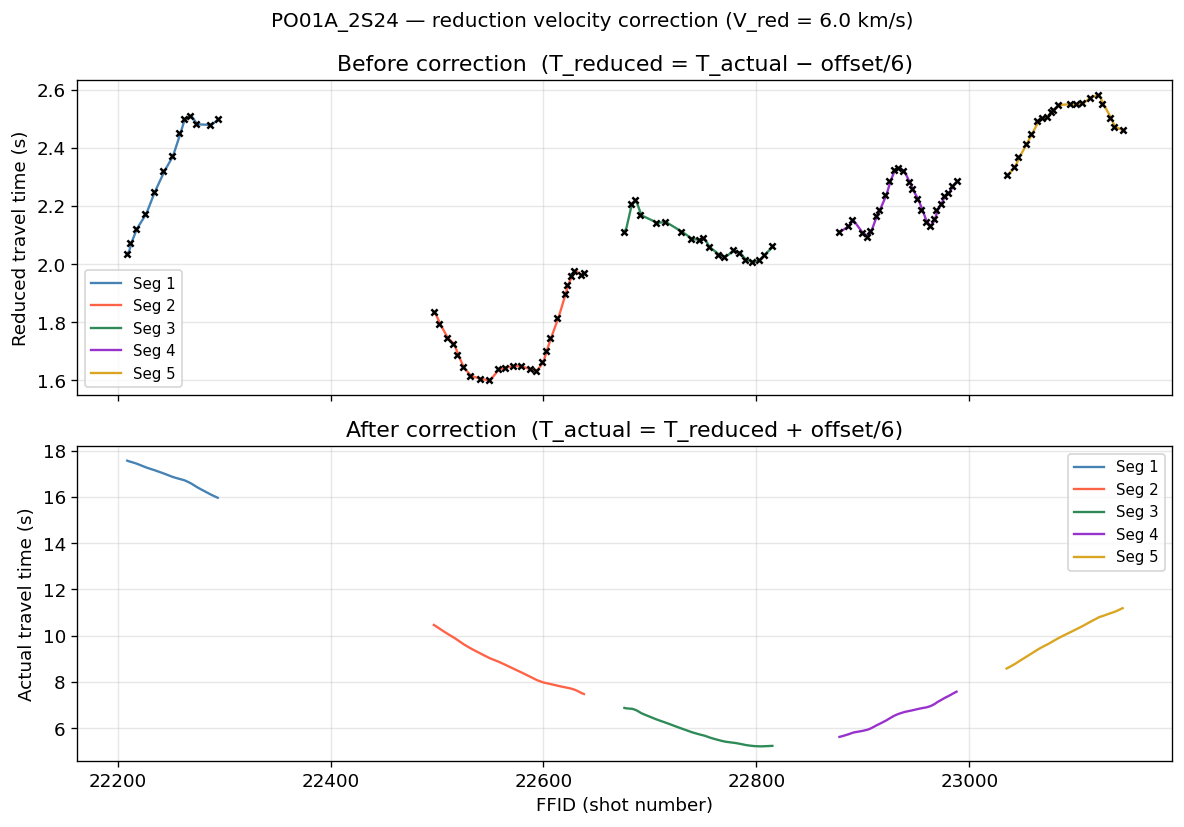

In [87]:
from math import radians, sin, cos, sqrt, atan2

REDUCTION_VELOCITY = 6.0  # km/s

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km."""
    R = 6371.0
    phi1, phi2 = radians(lat1), radians(lat2)
    dphi = radians(lat2 - lat1)
    dlam = radians(lon2 - lon1)
    a = sin(dphi / 2)**2 + cos(phi1) * cos(phi2) * sin(dlam / 2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


# Load shot positions
shotlog = pd.read_csv(BASE / "allshots_formatted.csv", low_memory=False,
                      usecols=["shot", "sourceLat", "sourceLon"])
shotlog = shotlog.dropna().astype({"shot": int}).set_index("shot")

# Load OBS position for this station  (PO01A_2S24 → station 2S24)
es_df   = pd.read_csv(BASE / "EarthScope_OBS_Deployments.csv")
obs_row = es_df[es_df["Station"] == "2S24"].iloc[0]
obs_lat, obs_lon = obs_row["Latitude"], obs_row["Longitude"]
print(f"OBS 2S24: lat={obs_lat}, lon={obs_lon}, depth={obs_row['Depth (km)']} km")

# Apply correction to the concatenated interpolated DataFrame
df_corrected = df_all.copy()
df_corrected = df_corrected.join(shotlog[["sourceLat", "sourceLon"]], on="FFID", how="left")

df_corrected["offset_km"] = df_corrected.apply(
    lambda row: haversine_km(row["sourceLat"], row["sourceLon"], obs_lat, obs_lon)
                if pd.notna(row["sourceLat"]) else float("nan"),
    axis=1
)
correction = df_corrected["offset_km"] / REDUCTION_VELOCITY
df_corrected["Time actual"]        = df_corrected["Time"]        + correction
df_corrected["Time Boxcar actual"] = df_corrected["Time Boxcar"] + correction

print(f"\nOffset range: {df_corrected['offset_km'].min():.1f} – "
      f"{df_corrected['offset_km'].max():.1f} km")
print(f"Correction range: {(correction).min():.3f} – {(correction).max():.3f} s")
print(f"\nReduced time range : {df_corrected['Time'].min():.3f} – "
      f"{df_corrected['Time'].max():.3f} s")
print(f"Actual  time range : {df_corrected['Time actual'].min():.3f} – "
      f"{df_corrected['Time actual'].max():.3f} s")

# Plot: reduced vs actual travel time
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for i, sdf in enumerate(seg_dfs):
    color = seg_colors[i % len(seg_colors)]
    # Get corrected rows for this segment's FFID range
    mask = df_corrected["FFID"].isin(sdf["FFID"])
    sub  = df_corrected[mask]
    axes[0].plot(sub["FFID"], sub["Time Boxcar"],        color=color, lw=1.4, label=f"Seg {i+1}")
    axes[1].plot(sub["FFID"], sub["Time Boxcar actual"], color=color, lw=1.4, label=f"Seg {i+1}")

axes[0].scatter(ffids_raw, times_raw, s=14, color="black", zorder=5, marker="x")
axes[0].set_ylabel("Reduced travel time (s)")
axes[0].set_title("Before correction  (T_reduced = T_actual − offset/6)")
axes[0].legend(fontsize=9)

axes[1].set_xlabel("FFID (shot number)")
axes[1].set_ylabel("Actual travel time (s)")
axes[1].set_title("After correction  (T_actual = T_reduced + offset/6)")
axes[1].legend(fontsize=9)

fig.suptitle(f"{TBL_FILE.stem} — reduction velocity correction (V_red = {REDUCTION_VELOCITY} km/s)",
             fontsize=12)
plt.tight_layout()
plt.show()

## 5 · Undo reduction velocity

The OBS data were displayed in Reveal with a **6 km/s reduction velocity**, meaning
the picked times are reduced times:

$$T_\text{reduced} = T_\text{actual} - \frac{\text{offset}}{6}$$

To recover actual travel times we add back the offset term:

$$T_\text{actual} = T_\text{reduced} + \frac{\text{offset}}{6}$$

where **offset** is the great-circle source–receiver distance in km, computed from
the FFID shot position (from `allshots_formatted.csv`) and the OBS deployment
position (from `EarthScope_OBS_Deployments.csv`).

## 6 · Effect of gap threshold

The gap threshold controls where segment boundaries are placed.  Too low and
normal picking gaps create spurious breaks; too high and the interpolation
bridges across genuine data gaps.  The plots below compare several threshold
values side-by-side to help choose an appropriate setting.

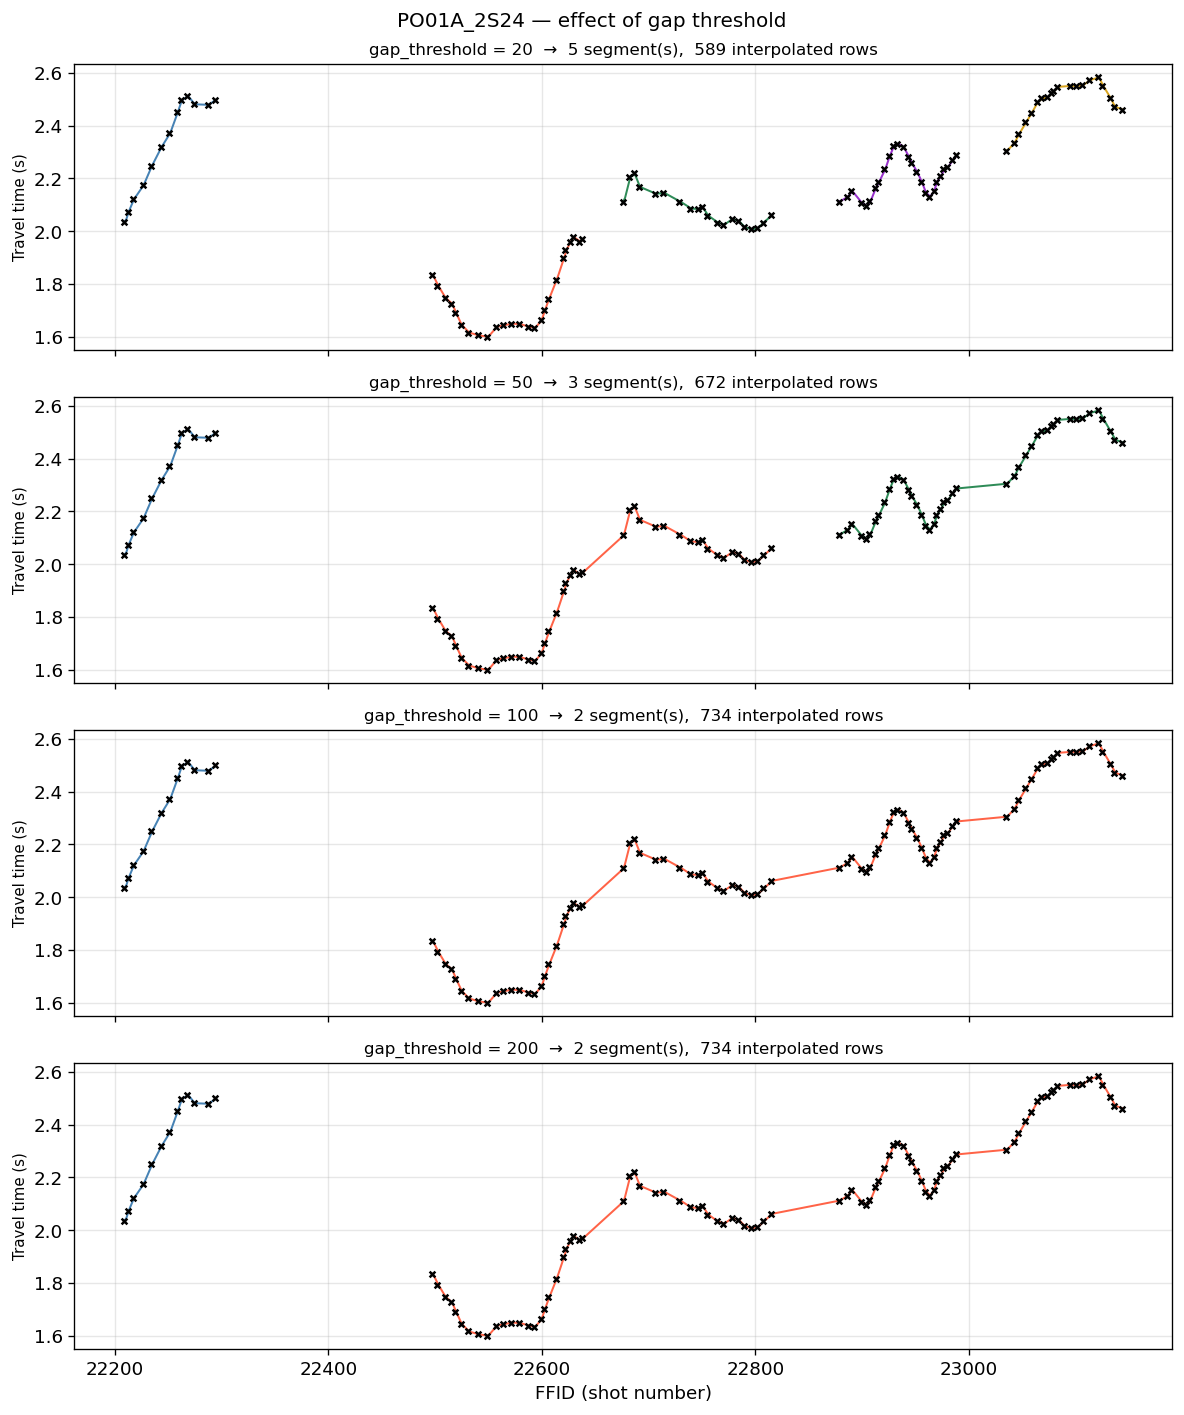

In [91]:
thresholds = [20, 50, 100, 200]

fig, axes = plt.subplots(len(thresholds), 1,
                         figsize=(10, 3 * len(thresholds)), sharex=True)

for ax, thresh in zip(axes, thresholds):
    segs = split_segments(raw_picks, thresh)
    sdfs = [interpolate_segment(s, BOXCAR_WINDOW) for s in segs]

    for i, sdf in enumerate(sdfs):
        color = seg_colors[i % len(seg_colors)]
        ax.plot(sdf["FFID"], sdf["Time Boxcar"], color=color, lw=1.2)

    ax.scatter(ffids_raw, times_raw, s=12, color="black", zorder=5, marker="x")
    ax.set_ylabel("Travel time (s)", fontsize=9)
    ax.set_title(
        f"gap_threshold = {thresh}  →  {len(segs)} segment(s),  "
        f"{sum(len(d) for d in sdfs)} interpolated rows",
        fontsize=10
    )

axes[-1].set_xlabel("FFID (shot number)")
fig.suptitle(f"{TBL_FILE.stem} — effect of gap threshold", fontsize=12)
plt.tight_layout()
plt.show()

## 7 · Final output preview

The processed CSV columns (same schema as Josh's master files for OBS picks):

In [ ]:
processed_csv = BASE / "tables" / "processed" / f"{TBL_FILE.stem}.csv"

if processed_csv.exists():
    df_out = pd.read_csv(processed_csv)
    print(f"Processed file: {processed_csv.name}")
    print(f"Rows: {len(df_out)}, Columns: {list(df_out.columns)}")
    display(df_out.head(10))
else:
    print(f"Processed file not found at {processed_csv}")
    print("Run  process_anne_picks.py  first to generate it.")
    # Show the in-notebook result instead
    print("\nShowing in-notebook interpolation result:")
    display(df_all[["FFID", "Time", "Time Boxcar"]].head(10))